0


/var/folders/0j/34jt056n1qd03z4ldfbf3d5r0000gn/T/ipykernel_13236/1115816914.py:26: UserWarning: Using torch.cross without specifying the dim arg is deprecated.
Please either pass the dim explicitly or simply use torch.linalg.cross.
The default value of dim will change to agree with that of linalg.cross in a future release. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/aten/src/ATen/native/Cross.cpp:67.)
  cross_product = torch.cross(k, v)


tensor(83.8425, grad_fn=<SumBackward0>)
Iteration 0: Normalized Gradient = 2.828824758529663, Adaptive learning rate = 0.001
1
tensor(85.0251, grad_fn=<SumBackward0>)
2
tensor(86.4358, grad_fn=<SumBackward0>)
3
tensor(88.0879, grad_fn=<SumBackward0>)
4
tensor(89.9941, grad_fn=<SumBackward0>)
5
tensor(92.1705, grad_fn=<SumBackward0>)
Iteration 5: Normalized Gradient = 20.64161491394043, Adaptive learning rate = 0.001
6
tensor(94.6331, grad_fn=<SumBackward0>)
7
tensor(97.3999, grad_fn=<SumBackward0>)
8
tensor(100.4894, grad_fn=<SumBackward0>)
9
tensor(103.9228, grad_fn=<SumBackward0>)
10
tensor(107.7220, grad_fn=<SumBackward0>)
Iteration 10: Normalized Gradient = 51.08799743652344, Adaptive learning rate = 0.001
11
tensor(111.9110, grad_fn=<SumBackward0>)
12
tensor(116.5158, grad_fn=<SumBackward0>)
13
tensor(121.5634, grad_fn=<SumBackward0>)
14
tensor(127.0840, grad_fn=<SumBackward0>)
15
tensor(133.1089, grad_fn=<SumBackward0>)
Iteration 15: Normalized Gradient = 104.67413330078125, Adap

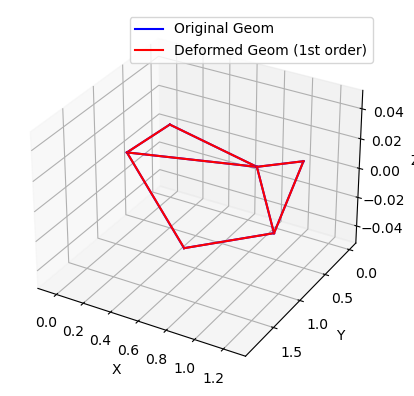

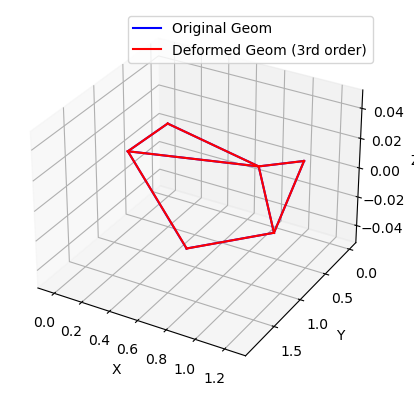

In [1]:
import torch
import torch.optim as optim
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
# Description:
# This script is based on the Euler-Bernoulli beam theory (Second-order shape function) with
# linear curvature (third-order curve). And all the deformation is linear
# with no directional coupling is considered



# Default values (in meters, Pascals, etc.)
D_width = 0.1
D_height = 0.2
D_young_modulus = 210e9  # Young's modulus in Pascals
D_shear_modulus = 81e9  # Shear modulus in Pascals
D_poisson_ratio = 0.3
n_dof_per_node = 6  # Degrees of freedom per node
cross_section_angle_a = 0  # Cross-section angle at node 1 (anti-clockwise)
cross_section_angle_b = 0  # Cross-section angle at node 2 (anti-clockwise)
a_small_number = 1e-10

def rotation(v, k, theta):
    """Rotation of vector v around axis k by angle theta."""
    k = k / torch.norm(k)  # Normalize k
    cross_product = torch.cross(k, v)
    dot_product = torch.dot(k, v)

    # Ensure theta is a tensor
    theta = torch.tensor(theta, dtype=torch.float32) if not isinstance(theta, torch.Tensor) else theta

    v_rotated = v * torch.cos(theta) + cross_product * torch.sin(theta) + k * dot_product * (1 - torch.cos(theta))
    return v_rotated


class Beam:
    def __init__(self, node_coordinates, width=D_width, height=D_height, young_modulus=D_young_modulus,
                 shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio, Beta_a=cross_section_angle_a,
                 Beta_b=cross_section_angle_b):
        self.node_coordinates = node_coordinates  # (2, 3) tensor for node coordinates

        # Material and geometry
        self.width = width
        self.height = height
        self.young_modulus = young_modulus
        self.shear_modulus = shear_modulus
        self.poisson_ratio = poisson_ratio

        # Cross-sectional properties
        self.length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])  # Length of the beam
        self.Iy = (self.width * self.height ** 3) / 12
        self.Iz = (self.width ** 3 * self.height) / 12
        self.A = self.width * self.height
        self.J = (self.width * self.height ** 3) / 3

        # Stiffness components
        self.S_u = self.young_modulus * self.A / self.length
        self.S_v1a = 12 * self.young_modulus * self.Iy / (self.length ** 3)
        self.S_v1b = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_v2a = 12 * self.young_modulus * self.Iz / (self.length ** 3)
        self.S_v2b = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta1a = 6 * self.young_modulus * self.Iy / (self.length ** 2)
        self.S_theta1b = 4 * self.young_modulus * self.Iy / self.length
        self.S_theta1c = 2 * self.young_modulus * self.Iy / self.length
        self.S_theta2a = 6 * self.young_modulus * self.Iz / (self.length ** 2)
        self.S_theta2b = 4 * self.young_modulus * self.Iz / self.length
        self.S_theta2c = 2 * self.young_modulus * self.Iz / self.length
        self.S_Tr = self.shear_modulus * self.J / self.length

        # Section rotations at the two ends
        self.Beta_a = Beta_a
        self.Beta_b = Beta_b

    def get_element_stiffness_matrix(self):
        """Element stiffness matrix."""
        K_element = torch.tensor([
            [self.S_u, 0, 0, 0, 0, 0, -self.S_u, 0, 0, 0, 0, 0],
            [0, self.S_v1a, 0, 0, 0, self.S_theta1a, 0, -self.S_v1a, 0, 0, 0, self.S_theta1a],
            [0, 0, self.S_v2a, 0, -self.S_theta2a, 0, 0, 0, -self.S_v2a, 0, -self.S_theta2a, 0],
            [0, 0, 0, self.S_Tr, 0, 0, 0, 0, 0, -self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2b, 0, 0, 0, self.S_v2b, 0, self.S_theta2c, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1b, 0, -self.S_v1b, 0, 0, 0, self.S_theta1c],
            [-self.S_u, 0, 0, 0, 0, 0, self.S_u, 0, 0, 0, 0, 0],
            [0, -self.S_v1a, 0, 0, 0, -self.S_theta1a, 0, self.S_v1a, 0, 0, 0, -self.S_theta1a],
            [0, 0, -self.S_v2a, 0, self.S_theta2a, 0, 0, 0, self.S_v2a, 0, self.S_theta2a, 0],
            [0, 0, 0, -self.S_Tr, 0, 0, 0, 0, 0, self.S_Tr, 0, 0],
            [0, 0, -self.S_v2b, 0, self.S_theta2c, 0, 0, 0, self.S_v2b, 0, self.S_theta2b, 0],
            [0, self.S_v1b, 0, 0, 0, self.S_theta1c, 0, -self.S_v1b, 0, 0, 0, self.S_theta1b],
        ], dtype=torch.float32)

        return K_element

    def System_Transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        # print(vector_x,vector_y,vector_z)
        # Calculate alpha and ceta using PyTorch
        z_value = torch.clamp(vector_z / length, min=-1+1e-6, max=1-1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1+1e-6, max=1-1e-6)
        alpha = torch.acos(value)
        # print(alpha)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi/2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)

        # Z_axis_b = rotation(V_projection, X_axis, self.Beta_b)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        # Y_axis_b = rotation(Z_axis_b, X_axis, torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        # Z_axis_b = Z_axis_b / torch.norm(Z_axis_b)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)
        # Y_axis_b = Y_axis_b / torch.norm(Y_axis_b)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)
        matrix_T = torch.zeros((12, 12), dtype=torch.float32)
        for i in range(0, 12, 3):
            matrix_T[i:i + 3, i:i + 3] = lambda_matrix
        return matrix_T

    def nodal_transform(self):
        """Coordinate transformation matrix."""
        vector_x = self.node_coordinates[1, 0] - self.node_coordinates[0, 0]
        vector_y = self.node_coordinates[1, 1] - self.node_coordinates[0, 1]
        vector_z = self.node_coordinates[1, 2] - self.node_coordinates[0, 2]
        length = torch.norm(self.node_coordinates[1] - self.node_coordinates[0])
        # Calculate alpha and ceta using PyTorch
        z_value = torch.clamp(vector_z / length, min=-1+1e-6, max=1-1e-6)
        ceta = torch.acos(z_value)
        value = vector_x / torch.sqrt(vector_y ** 2 + vector_x ** 2 + a_small_number)
        value = torch.clamp(value, min=-1+1e-6, max=1-1e-6)
        alpha = torch.acos(value)

        Projection_Z_x = - vector_z / length * torch.sin(alpha)
        Projection_Z_y = - vector_z / length * torch.cos(alpha)
        Projection_Z_z = torch.cos(torch.pi/2 - ceta)

        V_projection = torch.stack([Projection_Z_x, Projection_Z_y, Projection_Z_z])
        X_axis = torch.stack([vector_x / length, vector_y / length, vector_z / length])
        Z_axis_a = rotation(V_projection, X_axis, self.Beta_a)

        # Z_axis_b = rotation(V_projection, X_axis, self.Beta_b)
        Y_axis_a = rotation(Z_axis_a, X_axis, -torch.pi / 2)
        # Y_axis_b = rotation(Z_axis_b, X_axis, torch.pi / 2)
        Z_axis_a = Z_axis_a / torch.norm(Z_axis_a)
        # Z_axis_b = Z_axis_b / torch.norm(Z_axis_b)
        Y_axis_a = Y_axis_a / torch.norm(Y_axis_a)
        # Y_axis_b = Y_axis_b / torch.norm(Y_axis_b)

        lambda_matrix = torch.stack([X_axis, Y_axis_a, Z_axis_a], dim=0)

        return lambda_matrix

def assemble_stiffness_matrix(beams, n_nodes, n_dof_per_node, connectivity):
    """Global stiffness matrix assembly."""
    # connectivity = [[0,1],[1,2],[2,3]]
    total_dof = n_nodes * n_dof_per_node  # Total degrees of freedom
    K_global = torch.zeros((total_dof, total_dof), dtype=torch.float32)

    for idx, (i, j) in enumerate(connectivity):
        Matrix_T = beams[idx].System_Transform()  # Get transformation matrix

        K_element = torch.matmul(torch.transpose(Matrix_T, 0, 1),
                                 torch.matmul(beams[idx].get_element_stiffness_matrix(), Matrix_T))
        start_idx = i * n_dof_per_node
        end_idx = j * n_dof_per_node

        K_global[start_idx:start_idx + 6, start_idx:start_idx + 6] = K_global[start_idx:start_idx + 6, start_idx:start_idx + 6] + K_element[0:6, 0:6]
        K_global[end_idx:end_idx + 6, end_idx:end_idx + 6] = K_global[end_idx:end_idx + 6, end_idx:end_idx + 6] + K_element[6:12, 6:12]
        K_global[start_idx:start_idx + 6, end_idx:end_idx + 6] = K_global[start_idx:start_idx + 6, end_idx:end_idx + 6] + K_element[0:6, 6:12]
        K_global[end_idx:end_idx + 6, start_idx:start_idx + 6] = K_global[end_idx:end_idx + 6, start_idx:start_idx + 6] + K_element[6:12, 0:6]

    return K_global

def Strain_E(node_coords, Sel_cords, Sel_nodes, connectivity, fixed_dof, F, init_bias):
    for idx, sel_node in enumerate(Sel_nodes):
        node_coords[sel_node] = node_coords[sel_node] + init_bias * Sel_cords[idx]
    # node_coords[:, 2] = 0.0
    # Element Assembly
    beams = []
    for connection in connectivity:
        node_1_coords = node_coords[connection[0]]
        node_2_coords = node_coords[connection[1]]
        beam = Beam(node_coordinates=torch.stack([node_1_coords, node_2_coords]),
                    width=D_width, height=D_height,
                    young_modulus=D_young_modulus, shear_modulus=D_shear_modulus, poisson_ratio=D_poisson_ratio)
        beams.append(beam)

    # Stiffness renewal
    K_global = assemble_stiffness_matrix(beams, n_nodes=len(node_coords), n_dof_per_node=6, connectivity=connectivity)
    K_global[fixed_dof, :] = K_global[fixed_dof, :] - K_global[fixed_dof, :]
    K_global[:, fixed_dof] = K_global[:, fixed_dof] - K_global[:, fixed_dof]
    K_global[fixed_dof, fixed_dof] = 1e10
    t = [3]
    for t in t:
        for i in range(len(node_coords)):
            K_global[6 * i + t, :] = K_global[6 * i + t, :] - K_global[6 * i + t, :]
            K_global[:, 6 * i + t] = K_global[:, 6 * i + t] - K_global[:, 6 * i + t]
            K_global[6 * i + t, 6 * i + t] = 1e10

    rank_K = torch.linalg.matrix_rank(K_global)


    if rank_K < K_global.shape[0]:
        print("Warning: The stiffness matrix is not of full rank")
    else:
        displacements = torch.linalg.solve(K_global, F)

    # Compute strain energy
    strain_energy_list = []
    Local_d = torch.zeros(len(connectivity), 12, dtype=torch.float32)
    for n, (i, j) in enumerate(connectivity):
        matrix_T = beams[n].System_Transform()
        Tep_displacements = torch.cat([displacements[6 * i:6 * i + 6], displacements[6 * j:6 * j + 6]], dim=0)
        Local_d_n = torch.matmul(Tep_displacements, matrix_T.T)
        Local_d[n, :] = Local_d_n.clone()
        K_g = torch.matmul(torch.transpose(matrix_T, 0, 1),
                           torch.matmul(beams[n].get_element_stiffness_matrix(), matrix_T))

        strain_energy_list.append(torch.matmul(Local_d_n, torch.matmul(K_g, Local_d_n.reshape(-1, 1))))

    Strain_energy = torch.stack(strain_energy_list)

    return Strain_energy, Local_d, displacements, beams

# Element creating
#################  input below:
############################################################################################################## input
# initial coordinates
node_coords = torch.tensor([[0.0, 0.0, 0.0],[-0.5, 1.0, 0.0],[0.5, 1.5, 0.0],[0.5, 0.5, 0.0],[1.5, 1.0, 0.0],[1.0, 0.0, 0.0]],
                           dtype=torch.float32)
connectivity = [[0,1],[0,3],[1,2],[1,3],[2,4],[4,3],[4,5],[5,3]]
n_nodes = len(node_coords)
n_elements = len(connectivity)
total_dof = n_nodes * 6

####### Force condition
## +0 to x direction ; +1 to y direction ; +2 to Z direction
## +3 Bending around the z axis ; +4 bending around y axis ; +5 Twisting
F = torch.zeros(total_dof, dtype=torch.float32)
f_n = [3] # The nodes at which the force is implemented
f_type = [0] # The force type
F_value = torch.tensor([100.0]) # The force value/direction
F_sign = torch.sign(F_value)
for idx, i in enumerate(f_n):
    F[6 * (i - 1) + f_type[idx]] = F_value[idx] * 1000 # unit: KN / KN*m

####### BCs
fixed_nodes = [0,5]
fixed_dof = []
for node in fixed_nodes:
    fixed_dof.extend([node * 6 + i for i in range(6)])

####### Gradient descent
init_bias = 0.01
Sel_nodes = [1, 2, 3, 4]
step = 0.001
epochs = 50

####### Plotting
steps = 20 # steps for tracing deformation shape
###################################################################################################################################################


## Optimization
torch.autograd.set_detect_anomaly(True)
Sel_cords = (2 * torch.rand(len(Sel_nodes), 3, dtype=torch.float32) - 1).requires_grad_(True)
node_coords = node_coords.clone()
# Optimizer setting
optimizer = optim.Adam([Sel_cords], lr=step)
# Loop start
for iteration in range(epochs + 1):
    print(iteration)
    # Forwards
    Strain_energy, _, displacements, _ = Strain_E(node_coords, Sel_cords, Sel_nodes, connectivity, fixed_dof, F, init_bias)
    Total_EStrain = torch.sum(Strain_energy)
    print(Total_EStrain )
    # Backwards
    optimizer.zero_grad()
    Total_EStrain.backward(retain_graph=True)

    # Grad
    gradients = Sel_cords.grad
    frob_norm_inrow = torch.norm(gradients, p=2, dim=1, keepdim=True)
    gradients = gradients / frob_norm_inrow
    frob_norm = torch.norm(frob_norm_inrow)
    # print(gradients)
    # Coordinates renewal
    optimizer.step()

    # print iteration
    if iteration % 5 == 0:
        print(f"Iteration {iteration}: Normalized Gradient = {frob_norm}, Adaptive learning rate = {step}")
print("Optimization completed.")
# print("coordinates:",node_coords)
################################################################################################################################################
##



#############################################################################################################
# Visualization
# Coordinates assembly:
Coordinates = node_coords.reshape(-1)
print(Coordinates)
## Coordinates renewal:
New_Coordinates = torch.zeros(n_nodes * 3, dtype=torch.float32)
displacements = Strain_E(node_coords, Sel_cords, Sel_nodes, connectivity, fixed_dof, F, init_bias)[2]
# print("displacements:",displacements)
for n in range(n_nodes):
    New_Coordinates[3*n : 3*n+3] = Coordinates[3*n : 3*n+3] + displacements[6*n : 6*n+3]

x_orig = Coordinates[0::3]
y_orig = Coordinates[1::3]
z_orig = Coordinates[2::3]
z_orig = torch.zeros_like(z_orig)
x_new = New_Coordinates[0::3]
y_new = New_Coordinates[1::3]
# z_new = New_Coordinates[2::3]
z_new = torch.zeros_like(y_new)
# plot
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for connection in connectivity:
    i, j = connection
    ax.plot([x_orig[i].item(), x_orig[j].item()], [y_orig[i].item(), y_orig[j].item()], [z_orig[i].item(), z_orig[j].item()], color='blue')
    ax.plot([x_new[i].item(), x_new[j].item()], [y_new[i].item(), y_new[j].item()], [z_new[i].item(), z_new[j].item()], color='red')


# Plot the arrow
# for idx, i in enumerate(f_n):
#     if f_type[idx] == 0:
#         dx, dy, dz = F_sign[idx], 0, 0
#     elif f_type[idx] == 1:
#         dx, dy, dz = 0, F_sign[idx], 0
#     elif f_type[idx] == 2:
#         dx, dy, dz = 0, 0, F_sign[idx]
#     ax.quiver(
#         node_coords[i, 0].item(),  # 将Tensor转为标量
#         node_coords[i, 1].item(),
#         node_coords[i, 2].item(),
#         dx,
#         dy,
#         dz,
#         color='r',
#         length=0.1
#     )

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.invert_yaxis()

# node_label = f"F = {{{F_value}}} KN at node{{{f_n-1}}}"
# ax.text(0.1, -0.5, 1.6, node_label, color='black')

ax.legend(['Original Geom', 'Deformed Geom (1st order)'])

plt.show()

########################################################################################################################
# SHape function embedding:
# Define a function to compute local_d and global displacements for multiple x values between 0 and L
def compute_local_and_global_displacements(n_elements, beams, Local_d, steps):
    glob_mid_dis = torch.zeros(n_elements, 3 * (steps+1), dtype=torch.float32)  # Global displacements
    mid_coords = torch.zeros(n_elements, 3 * (steps+1), dtype=torch.float32)  # Store displacements for multiple points (20 points per segment)

    for n in range(n_elements):
        l = beams[n].length
        x_values = torch.linspace(0, l, steps=steps + 1)  # 20 points from 0 to L
        for i, x in enumerate(x_values):
            # Find the original coordinates for this point in the element
            # We interpolate to find the coordinates based on the x value.
            # The original coordinates of the element's two nodes (start and end)
            x1, y1, z1 = beams[n].node_coordinates[0, 0], beams[n].node_coordinates[0, 1], beams[n].node_coordinates[0, 2]  # First node
            x2, y2, z2 = beams[n].node_coordinates[1, 0], beams[n].node_coordinates[1, 1], beams[n].node_coordinates[1, 2]  # Second node

            # Interpolate to get the coordinates at the current x
            t = x / l  # Proportional distance from 0 to l
            interp_x = (1 - t) * x1 + t * x2
            interp_y = (1 - t) * y1 + t * y2
            interp_z = (1 - t) * z1 + t * z2

            # Calculate the local displacement for this point (same formula as before)
            disp_x = (1 - x / l) * Local_d[n, 0] + (x / l) * Local_d[n, 6]
            disp_y = (1 - 3 * x ** 2 / l ** 2 + 2 * x ** 3 / l ** 3) * Local_d[n, 1] + \
                     (x - 2 * x ** 2 / l + x ** 3 / l ** 2) * Local_d[n, 3] + \
                     (3 * x ** 2 / l ** 2 - 2 * x ** 3 / l ** 3) * Local_d[n, 7] + \
                     (-x ** 2 / l + x ** 3 / l ** 2) * Local_d[n, 9]
            disp_z = (1 - 3 * x ** 2 / l ** 2 + 2 * x ** 3 / l ** 3) * Local_d[n, 2] + \
                     (x - 2 * x ** 2 / l + x ** 3 / l ** 2) * Local_d[n, 4] + \
                     (3 * x ** 2 / l ** 2 - 2 * x ** 3 / l ** 3) * Local_d[n, 8] + \
                     (-x ** 2 / l + x ** 3 / l ** 2) * Local_d[n, 10]

            # Create a tensor for the displacements (x, y, z)
            tep_cords = torch.tensor([disp_x, disp_y, disp_z], dtype=torch.float32)  # Ensure it's a tensor of shape [3]

            # Apply the nodal transformation to compute global displacement
            M = beams[n].nodal_transform()  # Get nodal transformation matrix
            M = torch.transpose(M, 0, 1)  # Transpose M if needed
            Cords = torch.matmul(tep_cords, torch.linalg.inv(M))  # Apply transformation

            glob_mid_dis[n, 3*i : 3*i+3] = Cords
            # print(glob_mid_dis)
            # Now update the coordinates by adding global displacement to the interpolated coordinates
            new_x = interp_x + glob_mid_dis[n, 3*i]
            new_y = interp_y + glob_mid_dis[n, 3*i + 1]
            new_z = interp_z + glob_mid_dis[n, 3*i + 2]

            # Store the updated coordinates
            mid_coords[n, 3*i] = new_x
            mid_coords[n, 3*i + 1] = new_y
            mid_coords[n, 3*i + 2] = new_z

    return mid_coords, glob_mid_dis


Local_d = Strain_E(node_coords, Sel_cords, Sel_nodes, connectivity, fixed_dof, F, init_bias)[1]
beams = Strain_E(node_coords, Sel_cords, Sel_nodes, connectivity, fixed_dof, F , init_bias)[3]
mid_coords, glob_mid_dis = compute_local_and_global_displacements(n_elements, beams, Local_d,steps)
# print(glob_mid_dis)
# # print(mid_coords)

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
for connection in connectivity:
    i, j = connection
    ax.plot([x_orig[i].item(), x_orig[j].item()], [y_orig[i].item(), y_orig[j].item()], [z_orig[i].item(), z_orig[j].item()], color='blue')
    ax.plot([0, 0], [0, 0], [0, 0], color='red')

for n in range(mid_coords.shape[0]):
    x_vals = mid_coords[n, 0::3]
    y_vals = mid_coords[n, 1::3]
    # z_vals = mid_coords[n, 2::3]
    z_vals = torch.zeros_like(y_vals)
    ax.plot(x_vals.tolist(), y_vals.tolist(), z_vals.tolist(), color='red')

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.invert_yaxis()

# node_label = f"F = {{{F_value}}} KN at node{{{f_n-1}}}"
# ax.text(0.1, -0.5, 1.6, node_label, color='black')
ax.legend(['Original Geom', 'Deformed Geom (3rd order)'])

plt.show()